# 02 Augmentation and normalisation

Visual and numerical checks of the training time augmentations and the two coordinate normalisations in
`dataset.py`, run on the repaired keypoints before any model uses them.

The advanced policy has four techniques: limb rotation, confidence scaled noise, joint masking and temporal
warping. Their strengths are set relative to body height, so near and far players are treated alike.
Two of them were rewritten after the data audit; section 3 shows why.

Figures and tables are logged to ClearML (`BadmintonPoseAnalysis/data`, task `augmentation`).

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from clearml import Task

REPO = os.environ.get("BADMINTON_REPO", "/workspace/badminton-honours-project")
DATA = os.environ.get("BADMINTON_DATA", "/workspace/data")
sys.path.insert(0, REPO)
import dataset as ds

KEYPOINTS = f"{DATA}/keypoints_interp"
MIN_NATIVE_FRAMES = 5
SEED = 0
R_WRIST = 10

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

task = Task.init(project_name="BadmintonPoseAnalysis/data", task_name="augmentation",
                 task_type=Task.TaskTypes.data_processing, reuse_last_task_id=False,
                 auto_connect_frameworks={"matplotlib": False})
task.connect({"keypoints": KEYPOINTS, "min_native_frames": MIN_NATIVE_FRAMES, "seed": SEED})
logger = task.get_logger()


def publish(fig, title):
    logger.report_matplotlib_figure(title=title, series="augmentation", figure=fig,
                                    iteration=0, report_interactive=False)
    plt.show()


def publish_table(df, title):
    logger.report_table(title=title, series="augmentation", iteration=0, table_plot=df)
    return df

ClearML Task: created new task id=8ce3ac0106384112b646b338f4369722
2026-09-28 08:53:03,377 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/291d70d14da34608b9240b04ff61600c/tasks/8ce3ac0106384112b646b338f4369722/output/log


In [2]:
manifest = ds.load_filtered_manifest(f"{DATA}/split_manifest.csv", f"{DATA}/extraction_log.csv",
                                     f"{DATA}/keypoints_interp_log.csv", MIN_NATIVE_FRAMES)
train = manifest[manifest["split"] == "train"].reset_index(drop=True)
n_native = pd.read_csv(f"{DATA}/keypoints_interp_log.csv").set_index("filepath")["n_native"]


def load(row):
    stem = os.path.splitext(os.path.basename(row["filepath"]))[0]
    return np.load(f"{KEYPOINTS}/{row['class_name']}/{stem}.npy").astype(np.float32)


# a smash with plenty of real frames and a clear swing, used for every figure below
pool = train[(train["class_name"].str.endswith("Smash")) & ~train["class_name"].str.contains("Tap")]
pool = pool[pool["filepath"].map(n_native) >= 20]
rng = np.random.RandomState(SEED)
clip = load(pool.iloc[rng.randint(len(pool))])
speed = np.linalg.norm(np.diff(clip[:, R_WRIST, :2], axis=0), axis=1)
contact = int(speed.argmax()) + 1
print(f"example clip: body height {ds.body_height(clip):.0f} px, fastest wrist frame {contact}")

manual review: dropped 4 clips
short clip rule: dropped 4 train clips with fewer than 5 real frames
7810 clips remain (train 6247, test 782, val 781)
example clip: body height 138 px, fastest wrist frame 6


## 1. What each augmentation does

Grey is the original clip, colour the augmented one, drawn at five frames. Each column is an independent
random draw with the augmentation forced on (p = 1).

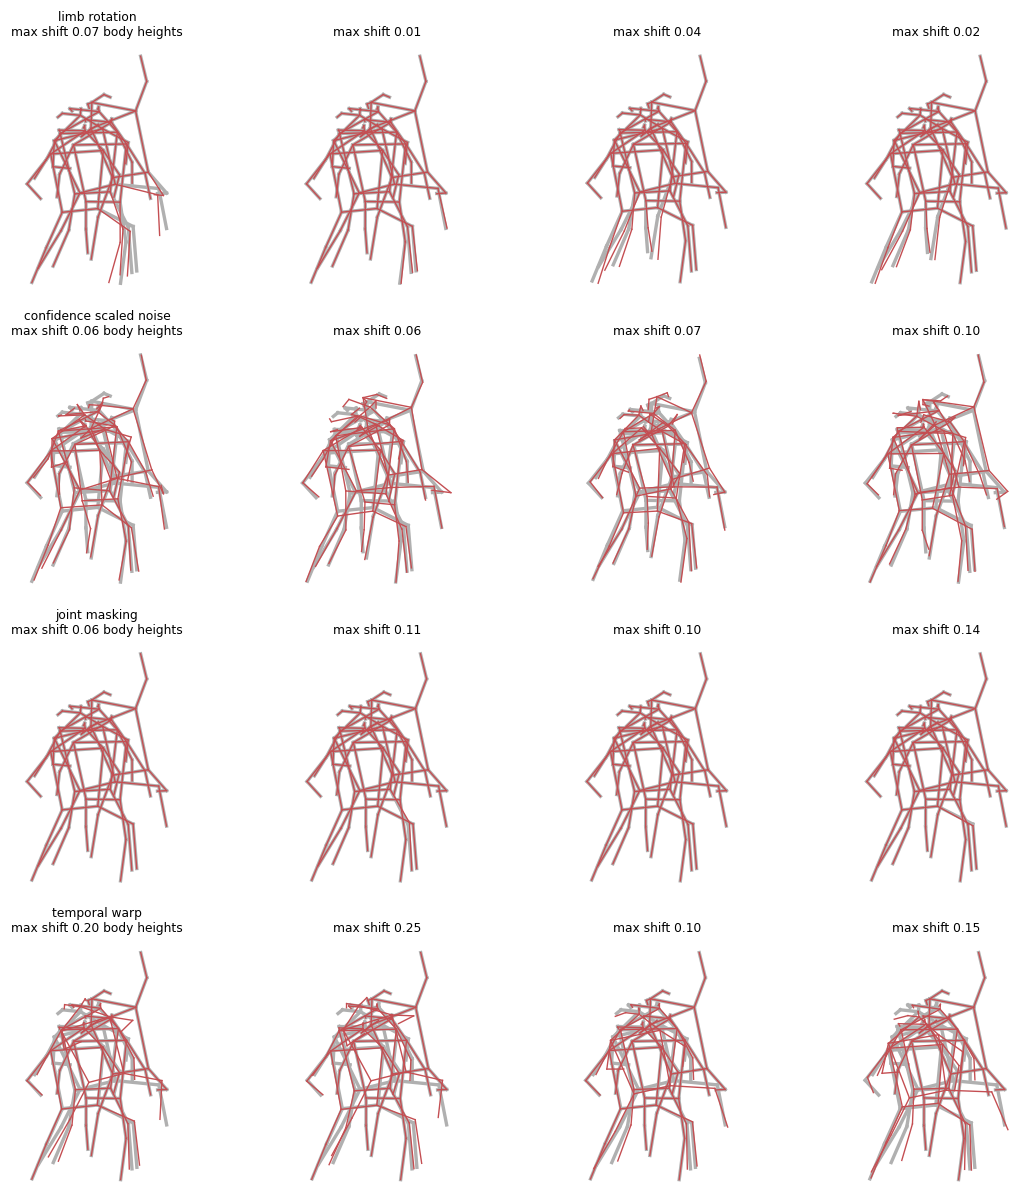

In [3]:
def draw(ax, kp, colour, lw, frames=np.linspace(0, 29, 5).astype(int)):
    for t in frames:
        for a, b in ds.COCO_SKELETON:
            ax.plot(kp[t, [a, b], 0], kp[t, [a, b], 1], color=colour, lw=lw)


augs = [("limb rotation", ds.aug_limb_rotation), ("confidence scaled noise", ds.aug_confidence_scaled_noise),
        ("joint masking", ds.aug_joint_masking), ("temporal warp", ds.aug_temporal_warp)]
np.random.seed(SEED)
fig, axes = plt.subplots(len(augs), 4, figsize=(11, 11))
for row, (name, fn) in zip(axes, augs):
    for col, ax in enumerate(row):
        out = fn(clip, p=1.0)
        draw(ax, clip, "#b0b0b0", 2.2)
        draw(ax, out, "#c44e52", 0.9)
        change = np.abs(out[..., :2] - clip[..., :2]).max() / ds.body_height(clip)
        ax.set_title(f"{name}\nmax shift {change:.2f} body heights" if col == 0 else f"max shift {change:.2f}", fontsize=8)
        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.axis("off")
fig.tight_layout()
publish(fig, "advanced augmentations, four draws each")

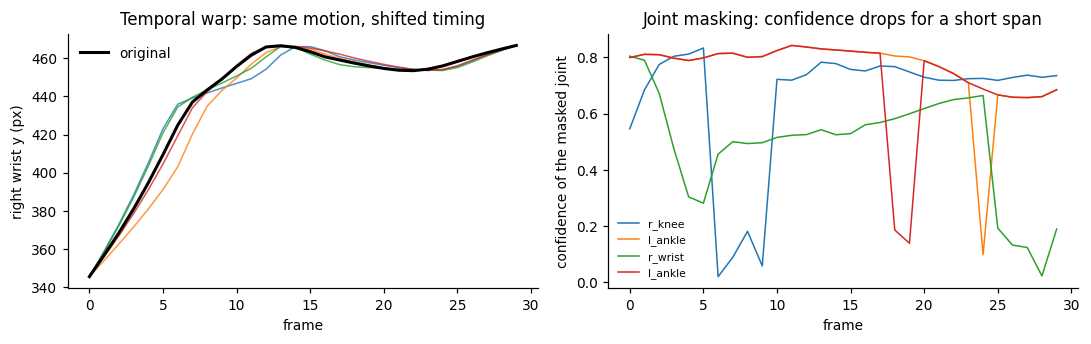

In [4]:
np.random.seed(SEED + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for i in range(4):
    warped = ds.aug_temporal_warp(clip, p=1.0)
    axes[0].plot(warped[:, R_WRIST, 1], lw=1, alpha=0.8)
axes[0].plot(clip[:, R_WRIST, 1], color="black", lw=2, label="original")
axes[0].set_xlabel("frame")
axes[0].set_ylabel("right wrist y (px)")
axes[0].set_title("Temporal warp: same motion, shifted timing")
axes[0].legend(frameon=False)

for i in range(4):
    masked = ds.aug_joint_masking(clip, max_joints=1, p=1.0)
    j = int(np.abs(masked[..., 2] - clip[..., 2]).sum(axis=0).argmax())
    axes[1].plot(masked[:, j, 2], lw=1, label=ds.JOINT_NAMES[j])
axes[1].set_xlabel("frame")
axes[1].set_ylabel("confidence of the masked joint")
axes[1].set_title("Joint masking: confidence drops for a short span")
axes[1].legend(frameon=False, fontsize=7)
fig.tight_layout()
publish(fig, "temporal warp and masking over time")

## 2. Checks on 500 training clips

Each augmentation is applied with p = 1 to 500 random training clips and checked against what it is meant to
do. Distances are in body heights.

In [5]:
def bone_lengths(kp):
    return np.linalg.norm(kp[:, [a for a, _ in ds.COCO_SKELETON], :2] - kp[:, [b for _, b in ds.COCO_SKELETON], :2], axis=2)


np.random.seed(SEED)
sample = train.sample(500, random_state=SEED)
stats = {k: [] for k in ["rot_bone", "rot_static", "noise", "mask_shift", "mask_conf", "warp_end", "mirror"]}
all_limbs = {j for chain in ds.LIMB_CHAINS.values() for j in chain}
for _, r in sample.iterrows():
    kp = load(r)
    h = ds.body_height(kp)

    out = ds.aug_limb_rotation(kp, p=1.0)
    stats["rot_bone"].append(np.abs(bone_lengths(out) - bone_lengths(kp)).max() / h)
    static = [j for j in range(17) if j not in all_limbs]
    stats["rot_static"].append(np.abs(out[:, static, :2] - kp[:, static, :2]).max() / h)

    out = ds.aug_confidence_scaled_noise(kp, p=1.0)
    stats["noise"].append(np.abs(out[..., :2] - kp[..., :2]).mean() / h)

    out = ds.aug_joint_masking(kp, p=1.0)
    touched = np.abs(out[..., :2] - kp[..., :2]).max(axis=-1) > 1e-6
    stats["mask_shift"].append(np.abs(out[..., :2] - kp[..., :2]).max() / h)
    stats["mask_conf"].append(out[..., 2][touched].max() if touched.any() else 0.0)

    out = ds.aug_temporal_warp(kp, p=1.0)
    stats["warp_end"].append(max(np.abs(out[0] - kp[0]).max(), np.abs(out[-1] - kp[-1]).max()))

    out = ds.aug_basic_mirror(ds.aug_basic_mirror(kp, p=1.0), p=1.0)
    stats["mirror"].append(np.abs(out - kp).max())

stats = {k: np.array(v) for k, v in stats.items()}
checks = pd.DataFrame([
    ("limb rotation keeps bone lengths", "max bone length change", stats["rot_bone"].max(), stats["rot_bone"].max() < 1e-3),
    ("limb rotation leaves head and torso alone", "max shift of non limb joints", stats["rot_static"].max(), stats["rot_static"].max() < 1e-6),
    ("noise is small", "mean shift", stats["noise"].mean(), stats["noise"].mean() < 0.05),
    ("masked joints stay near the body", "max shift", stats["mask_shift"].max(), stats["mask_shift"].max() < 0.5),
    ("masked joints report low confidence", "max confidence", stats["mask_conf"].max(), stats["mask_conf"].max() <= 0.2),
    ("warp keeps first and last frame", "max change at endpoints", stats["warp_end"].max(), stats["warp_end"].max() < 1e-3),
    ("mirroring twice returns the original", "max difference", stats["mirror"].max(), stats["mirror"].max() < 1e-3),
], columns=["check", "measure", "value", "pass"])
checks["value"] = checks["value"].astype(float).round(6)
publish_table(checks, "augmentation checks")

,check,measure,value,pass
0,limb rotation keeps bone lengths,max bone length change,0.000001,True
1,limb rotation leaves head and torso alone,max shift of non limb joints,0.000000,True
2,noise is small,mean shift,0.010755,True
3,masked joints stay near the body,max shift,0.403032,True
4,masked joints report low confidence,max confidence,0.199987,True
5,warp keeps first and last frame,max change at endpoints,0.000000,True
6,mirroring twice returns the original,max difference,0.000366,True


## 3. Why two augmentations were rewritten

The earlier implementation had two problems found in the data audit, reproduced here on the same clip.

**Bone rotation.** It rotated a subtree of a skeleton tree rooted at the nose. In that tree the hips hang off the
shoulders, so picking a shoulder as the pivot swung the arm and the leg on that side together. The new version
rotates anatomical limb chains only.

**Joint masking.** It set masked coordinates to zero. In pixel units that is the top left corner of the frame,
roughly 800 px from the player, and temporal warping afterwards smeared the jump into neighbouring frames. The
new version keeps the joint near its true path with near zero confidence, which is how the pose model reports
an occluded joint.

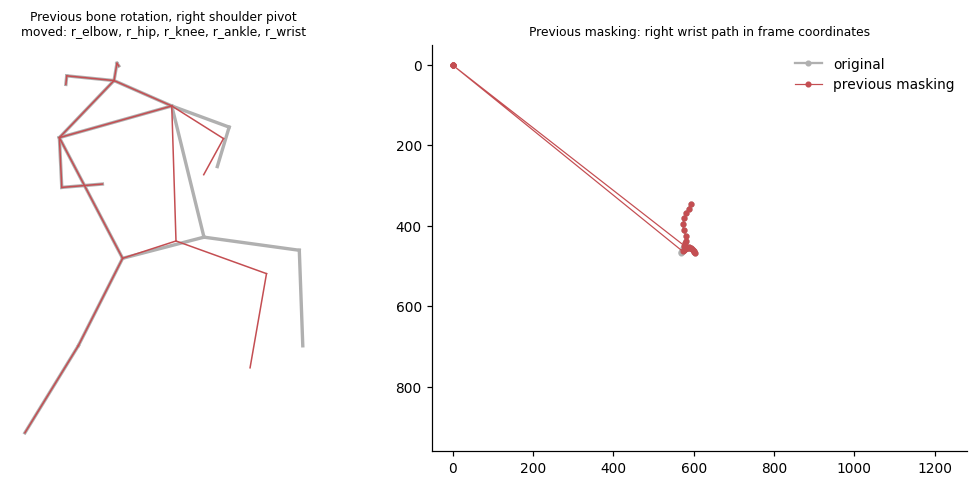

In [6]:
def previous_bone_rotation(kp, pivot, angle_deg):
    # earlier implementation, pivot fixed so the effect is visible
    children = {i: [] for i in range(17)}
    for child, parent in enumerate(ds.PARENT):
        if child != parent:
            children[parent].append(child)
    subtree, stack = [], [pivot]
    while stack:
        for c in children[stack.pop()]:
            subtree.append(c)
            stack.append(c)
    a = np.radians(angle_deg)
    rot = np.array([[np.cos(a), -np.sin(a)], [np.sin(a), np.cos(a)]], dtype=np.float32)
    out = kp.copy()
    out[:, subtree, :2] = kp[:, pivot:pivot + 1, :2] + (kp[:, subtree, :2] - kp[:, pivot:pivot + 1, :2]) @ rot.T
    return out, subtree


old_rot, subtree = previous_bone_rotation(clip, pivot=6, angle_deg=12)
old_mask = clip.copy()
old_mask[10:15, R_WRIST, :] = 0.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
draw(axes[0], clip, "#b0b0b0", 2.2, frames=[contact])
draw(axes[0], old_rot, "#c44e52", 1.0, frames=[contact])
axes[0].set_title("Previous bone rotation, right shoulder pivot\nmoved: " + ", ".join(ds.JOINT_NAMES[j] for j in subtree), fontsize=8)
axes[0].set_aspect("equal")
axes[0].invert_yaxis()
axes[0].axis("off")

axes[1].plot(clip[:, R_WRIST, 0], clip[:, R_WRIST, 1], "o-", ms=3, color="#b0b0b0", label="original")
axes[1].plot(old_mask[:, R_WRIST, 0], old_mask[:, R_WRIST, 1], "o-", ms=3, color="#c44e52", lw=0.8, label="previous masking")
axes[1].set_xlim(-50, 1280)
axes[1].set_ylim(960, -50)
axes[1].set_title("Previous masking: right wrist path in frame coordinates", fontsize=8)
axes[1].legend(frameon=False)
fig.tight_layout()
publish(fig, "previous implementation issues")

## 4. Class balanced sampling

Classes below 500 training clips are drawn with replacement up to 500 per epoch, every draw augmented
independently. Larger classes are seen once each. This lifts the rare classes without cutting the common ones.

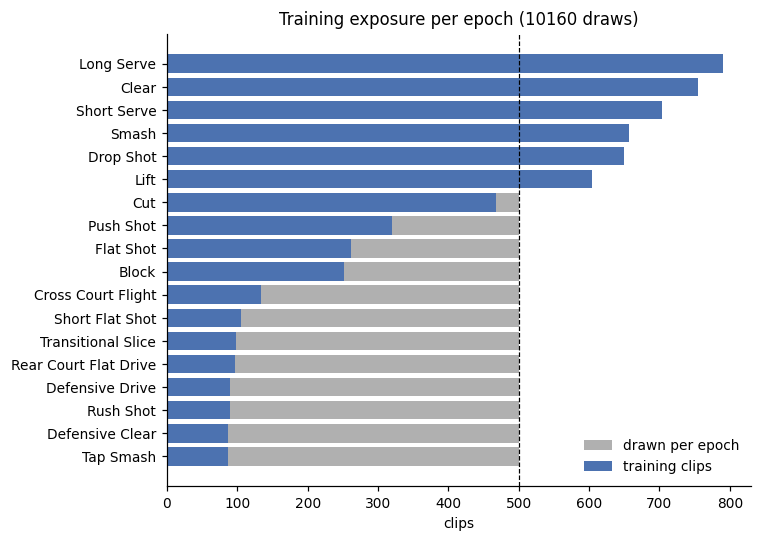

,class,natural,per epoch,repeats per clip
0,03_Tap Smash,87,500,5.7
1,10_Defensive Clear,87,500,5.7
2,09_Rush Shot,89,500,5.6
3,11_Defensive Drive,89,500,5.6
4,16_Rear Court Flat Drive,97,500,5.2
5,07_Transitional Slice,98,500,5.1
6,17_Short Flat Shot,105,500,4.8
7,01_Cross Court Flight,133,500,3.8
8,04_Block,252,500,2.0
9,15_Flat Shot,262,500,1.9


In [7]:
sampler = ds.build_class_balanced_sampler(train, target_per_class=500, seed=SEED)
drawn = pd.Series(train.loc[list(iter(sampler)), "class_name"]).value_counts()
natural = train["class_name"].value_counts()
exposure = pd.DataFrame({"natural": natural, "per epoch": drawn}).sort_values("natural")
exposure["repeats per clip"] = (exposure["per epoch"] / exposure["natural"]).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
names = [c.split("_", 1)[1] for c in exposure.index]
ax.barh(names, exposure["per epoch"], color="#b0b0b0", label="drawn per epoch")
ax.barh(names, exposure["natural"], color="#4c72b0", label="training clips")
ax.axvline(500, color="black", ls="--", lw=0.8)
ax.set_xlabel("clips")
ax.set_title(f"Training exposure per epoch ({len(sampler)} draws)")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
publish(fig, "class balanced sampling")
publish_table(exposure.rename_axis("class").reset_index(), "sampler exposure per class")

## 5. Normalisation options

The models are compared with two coordinate systems. **pixel** keeps the stored image coordinates, so where the
player stands and how large they appear are both visible to the model. **body** centres each clip on its mean hip
position and divides by body height, removing both. A third option adds the hip position back as a separate
`court` input (frame units, 0 to 1) so court position is available without body size. The data audit showed body
size and position also identify the drill sessions, which is what this comparison is testing.

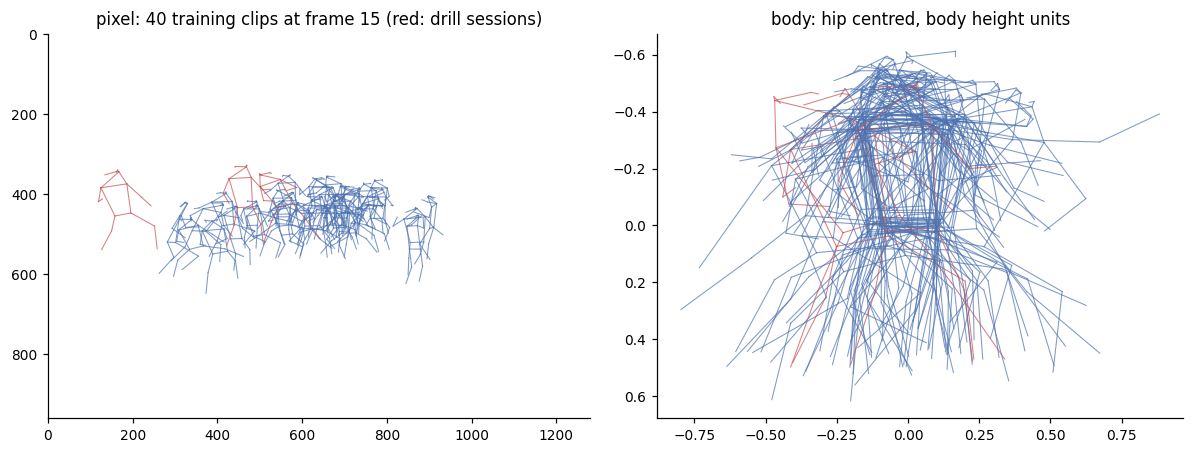

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
picks = train.sample(40, random_state=SEED)
for _, r in picks.iterrows():
    kp = load(r)
    drill = "2023-05-02" in r["filepath"]
    colour = "#c44e52" if drill else "#4c72b0"
    body = ds.normalise_body(kp)
    for ax, arr in [(axes[0], kp), (axes[1], body)]:
        t = 15
        for a, b in ds.COCO_SKELETON:
            ax.plot(arr[t, [a, b], 0], arr[t, [a, b], 1], color=colour, lw=0.7, alpha=0.7)
axes[0].set_xlim(0, 1280)
axes[0].set_ylim(960, 0)
axes[0].set_title("pixel: 40 training clips at frame 15 (red: drill sessions)")
axes[1].invert_yaxis()
axes[1].set_aspect("equal")
axes[1].set_title("body: hip centred, body height units")
fig.tight_layout()
publish(fig, "normalisation options")

In [9]:
task.close()